In [89]:
from tasks.scfoundation import load
import scipy.sparse as sp
import anndata as ad
import hdf5plugin
import pandas as pd
import numpy as np
import scanpy as sc
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [90]:
def prepare_data(adata, need_normalization=True):
    gene_list_df = pd.read_csv(f'{tokenizer_dir}/OS_scRNA_gene_index.19264.tsv', header=0, delimiter='\t')
    gene_list = list(gene_list_df['gene_name'])
    adata = adata[:,adata.var['gene_name'].isin(gene_list)]
    
    gexpr_feature = adata.X.A
    idx = adata.obs_names.tolist()
    col = adata.var['gene_name'].tolist()
    gexpr_feature = pd.DataFrame(gexpr_feature, index=idx, columns=col)
    gexpr_feature, _ = load.main_gene_selection(gexpr_feature, gene_list)

    varnames = gexpr_feature.columns.values
    matrix = sp.csr_matrix(gexpr_feature.values)
    adata_pp = ad.AnnData(X=matrix, obs=adata.obs, var=pd.DataFrame({}, index=varnames), obsm=adata.obsm)

    if need_normalization:
        sc.pp.normalize_total(adata_pp, target_sum=1e4)
        sc.pp.log1p(adata_pp)

    return(adata_pp)

In [91]:
def get_niche_radius(spatial_coords, max_niche_cell_num):
    distances = cdist(spatial_coords, spatial_coords)
    radius = 0
    counts = np.sum(distances < radius, axis=1)
    while max(counts) <= max_niche_cell_num:
        # print(radius, max(counts))
        radius += 0.0001
        counts = np.sum(distances < radius, axis=1)
    return radius-0.0001

def get_niche_samples(adata, spatial_coords, niche_radius, ligand_index, max_niche_cell_num=None):
    all_counts = adata.X.A
    cell_types_index = adata.obs['cell_type'].values

    niche_ligands_expression = []
    niche_composition = []
    niche_celltypes = np.zeros([adata.shape[0], 50])

    distances = cdist(spatial_coords, spatial_coords)
    for i in range(len(all_counts)):
        distances_i = distances[i]

        if niche_radius is None:
            niche_cells = np.argsort(distances_i)[:max_niche_cell_num]
        else:
            niche_cells = np.where(distances_i <= niche_radius)[0]
        
        niche_counts = np.concatenate([all_counts[niche_cells][:,ligand_index], np.zeros([50-len(niche_cells), 986])])
        niche_counts = np.concatenate(niche_counts)
        niche_ligands_expression.append(np.expand_dims(niche_counts, axis=0))

        niche_prop = np.concatenate([np.array([1]*len(niche_cells)), np.array([0]*(50-len(niche_cells)))])
        niche_prop = niche_prop/niche_prop.sum()
        niche_composition.append(np.expand_dims(niche_prop, axis=0))

        niche_celltypes[i, :len(niche_cells)] = cell_types_index[niche_cells]

    niche_ligands_expression = sp.csr_matrix(np.concatenate(niche_ligands_expression))
    niche_composition = sp.csr_matrix(np.concatenate(niche_composition))
    niche_celltypes = sp.csr_matrix(niche_celltypes)

    adata.X = adata.X.astype(np.float32)

    if max_niche_cell_num is None:
        adata.obsm['niche_composition'] = niche_composition.astype(np.float32)
        adata.obsm['niche_ligands_expression'] = niche_ligands_expression.astype(np.float32)
        adata.obsm['niche_celltypes'] = niche_celltypes.astype(np.float32)
    else:
        adata.obsm[f'niche_composition_niche{max_niche_cell_num}'] = niche_composition.astype(np.float32)
        adata.obsm[f'niche_ligands_expression_niche{max_niche_cell_num}'] = niche_ligands_expression.astype(np.float32)
        adata.obsm[f'niche_celltypes_niche{max_niche_cell_num}'] = niche_celltypes.astype(np.float32)
    
    return(adata)

In [92]:
tokenizer_dir = '../../stformer/tokenizer/'

gene_list_df = pd.read_csv(f'{tokenizer_dir}/OS_scRNA_gene_index.19264.tsv', header=0, delimiter='\t')
ligand_database = pd.read_csv(tokenizer_dir+'ligand_database.csv', header=0, index_col=0)
ligand_symbol = ligand_database[ligand_database.sum(1)>1].index.values
ligand_index = gene_list_df.loc[gene_list_df['gene_name'].isin(ligand_symbol), 'index'].values

In [93]:
adata = sc.read_h5ad(f'../../datasets/liver_cosmx_rds/liver_cosmx.h5ad')
adata

AnnData object with n_obs × n_vars = 793318 × 1000
    obs: 'cell_id', 'fov', 'Run_Tissue_name', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'qcFlagsFOV', 'cellType', 'niche'
    var: 'gene_name'

In [94]:
adata = adata[adata.obs['Run_Tissue_name']=='CancerousLiver']
adata = adata[adata.obs['qcFlagsFOV']=='Pass']
adata.obs['cell_type'] = adata.obs['cellType']
adata.obsm['spatial'] = adata.obs[['x_slide_mm', 'y_slide_mm']].values
adata = adata[adata.obs['fov'].isin(list(range(371,384)))]
adata

/tmp/ipykernel_107945/3630513197.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type'] = adata.obs['cellType']


View of AnnData object with n_obs × n_vars = 13374 × 1000
    obs: 'cell_id', 'fov', 'Run_Tissue_name', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'qcFlagsFOV', 'cellType', 'niche', 'cell_type'
    var: 'gene_name'
    obsm: 'spatial'

/home/shcao/miniconda3/envs/stformer/lib/python3.11/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/shcao/miniconda3/envs/stformer/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/shcao/miniconda3/envs/stformer/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: xlabel='spatial1', ylabel='spatial2'>

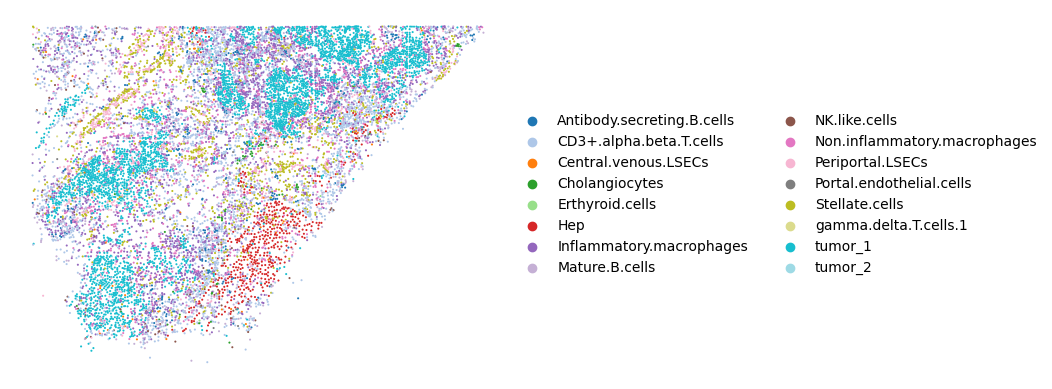

In [95]:
sc.pl.embedding(
    adata,
    basis='spatial',           
    color='cell_type',
    # size=30,                   
    palette='tab20',          
    frameon=False,
    title='',
    show=False,
)

# plt.savefig('liver_TME.pdf', 
#            bbox_inches='tight',
#            pad_inches=0)

In [ ]:
adata = prepare_data(adata, need_normalization=True)
#--------- Prepare sample data from single-cell spatial data ------------------
cell_types_list = adata.obs['cell_type'].cat.categories.tolist()
adata.obs['cell_type'] = adata.obs['cell_type'].cat.codes.values+1

max_niche_cell_num = 20
spatial_coords = adata.obsm['spatial']
niche_radius = get_niche_radius(spatial_coords, max_niche_cell_num)
print(niche_radius)
adata0 = get_niche_samples(adata, spatial_coords, niche_radius, ligand_index)

adata0.uns['cell_types_list'] = cell_types_list

0.01739999999999995


In [99]:
adata0

AnnData object with n_obs × n_vars = 13374 × 19264
    obs: 'cell_id', 'fov', 'Run_Tissue_name', 'x_FOV_px', 'y_FOV_px', 'x_slide_mm', 'y_slide_mm', 'qcFlagsFOV', 'cellType', 'niche', 'cell_type'
    uns: 'log1p', 'cell_types_list'
    obsm: 'spatial', 'niche_composition', 'niche_ligands_expression', 'niche_celltypes'

In [112]:
adata0.write('liver_cosmx_TME_niche.h5ad')